# 02 Text analysis: H1 metrics, brainrot vocabulary, sentiment (Phase 3)
Working notebook. Figures C10-C18 and C36. The story is merged into `eda.ipynb` later.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd
from src.viz import set_style, GROUP_COLORS, SUB_COLORS, ACCENT, GRAY, save, finding_title, caption, event_line, highlight_vs_gray
from src.config import AGG, EXT, EVENTS, GROUPS
set_style()

## How the text is measured
- **Words.** One tokenizer for numerator and denominator: lower-cased text without URLs, typographic apostrophes straightened, words = runs of letters, digits and apostrophes. Comments and submissions are measured separately; most charts use comments.
- **Rates per 10,000 words, not per comment.** Comment length itself changes (H1), so counts per comment would be biased. We also report *reach*, the share of comments with at least one hit.
- **Months with fewer than 50,000 words** in the sample are dropped from rate charts (a few hundred comments make a rate meaningless).
- **Brainrot lexicon, three tiers.** *Core*: brain rot (also brainrot, brain-rot, brainrotted), skibidi. *Extended*: rizz (rizzler, rizzed, rizzing), gyatt, fanum tax, mewing, tralalero, tung tung. *Ambiguous*, reported separately: sigma (half slang, half Greek letter, a novel series called Sigma Force, Six Sigma, a fraternity). *Doomscrolling*: doomscroll\*, doom scroll\*, doom surf\*.
- **Hand check.** We read 50 random matches in context for each of core and extended, 30 for sigma and 20 for doomscrolling. Core: all 50 are real uses or mentions of the term (several are people asking what it means; we count mentions, not endorsements). Extended: 48 of 50 are the slang; the other two were the ship USS Gyatt and a pun on "Rizzard of Oz". A first version of the pattern also matched "Rizzoli", which is why it is now restricted to rizz, rizzler, rizzed, rizzing, rizzes, rizzy. Sigma: about 70% slang. Doomscrolling: 20 of 20. We checked 50 instead of the planned 100 per tier and the check was done by one reader.
- **Samples.** Everything comes from the time-slot sample (see notebook 01). MTLD, readability and sentiment use fixed-size random samples per subreddit-month (5,000 words, 400 comments, 2,000 comments) so that months of different volume are comparable.

### Q10. Is the typical comment getting shorter? (H1)
**Why we asked:** This is the core of H1; Q5 only showed that communities differ in level.

**What we did:** Median words per comment for every subreddit-month (bots, moderator messages, templates and spam removed), 12-month mean of the monthly medians, months under 50,000 words dropped. One line per subreddit in its group color.

**Result:** Not a steady shrink. r/teenagers fell from 16 words (2012) to a low of 5 in August 2022 and is now at 7. r/memes went from 9 (January 2017, its first month with enough text) to 6 in June 2019 and is now at 12. The long-form communities are flat: r/books 24 to 27, r/explainlikeimfive 30 to 31, r/todayilearned 15 to 16.

**Interpretation:** H1 holds for the short-form communities only until 2019 (r/memes) or 2022 (r/teenagers); since then comments got longer again. 'Discourse is getting shorter' is not supported as a general trend in these data. Caution on the fall itself: r/teenagers grew from 0.6M to 22M comments a year between 2012 and 2022 (monthly totals), so it may reflect who joined and what is posted, not the same people writing less.

**Next question:** How many comments are extremely short (Q11), and is vocabulary getting poorer (Q12)?

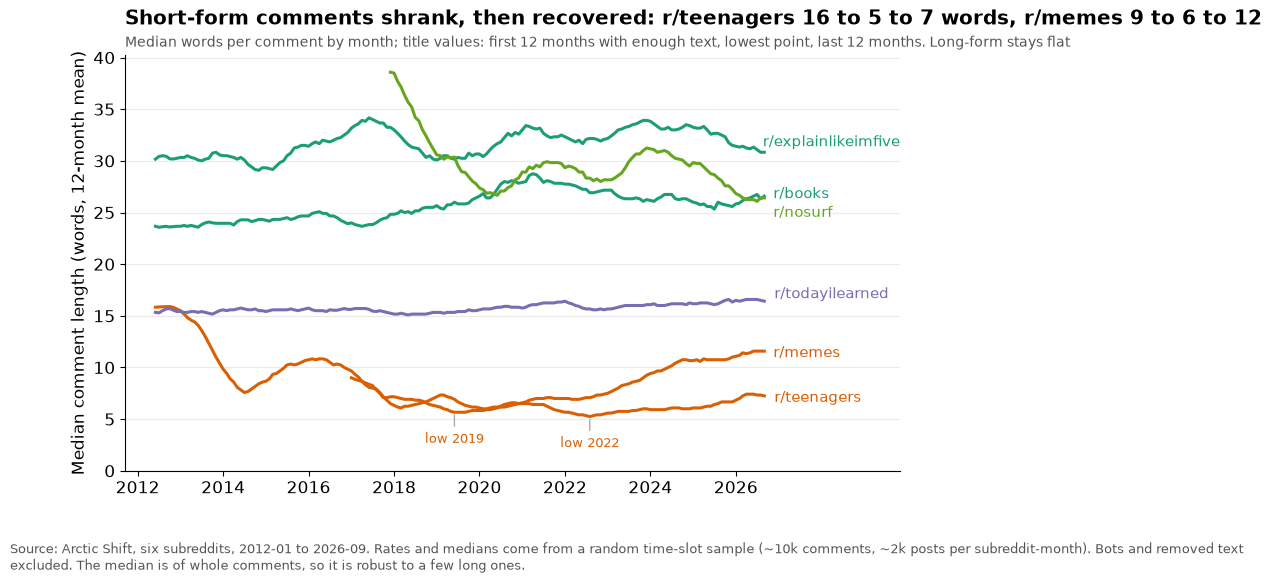

In [2]:
from src import figs_text as figs
_ = figs.c10()
plt.show()

**Code for C10:** `src/figs_text.py` function `c10()`; reads `overview_counts`; built by `python run_pipeline.py aggregates`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q11. What share of comments are very short (5 words or fewer)?
**Why we asked:** A median can hide a growing pile of one-liners.

**What we did:** Share of comments with 5 words or fewer per subreddit-month, 12-month mean, same filters as Q10.

**Result:** In r/teenagers the share rose from 19% (2012) to 51% in August 2022 and is now 41%. In r/memes it went from 33% (2017) to 50% in September 2019 and is now 24%. Long-form communities stay between 7% and 18%: r/books 11% to 8%, r/explainlikeimfive 10% to 7%, r/todayilearned 17% to 15%.

**Interpretation:** Same arc as the median: a rise in one-liners until 2019 or 2022 and a retreat since. At the peak half of all comments in the two short-form communities had five words or fewer.

**Next question:** Do shorter comments also use fewer different words (Q12)?

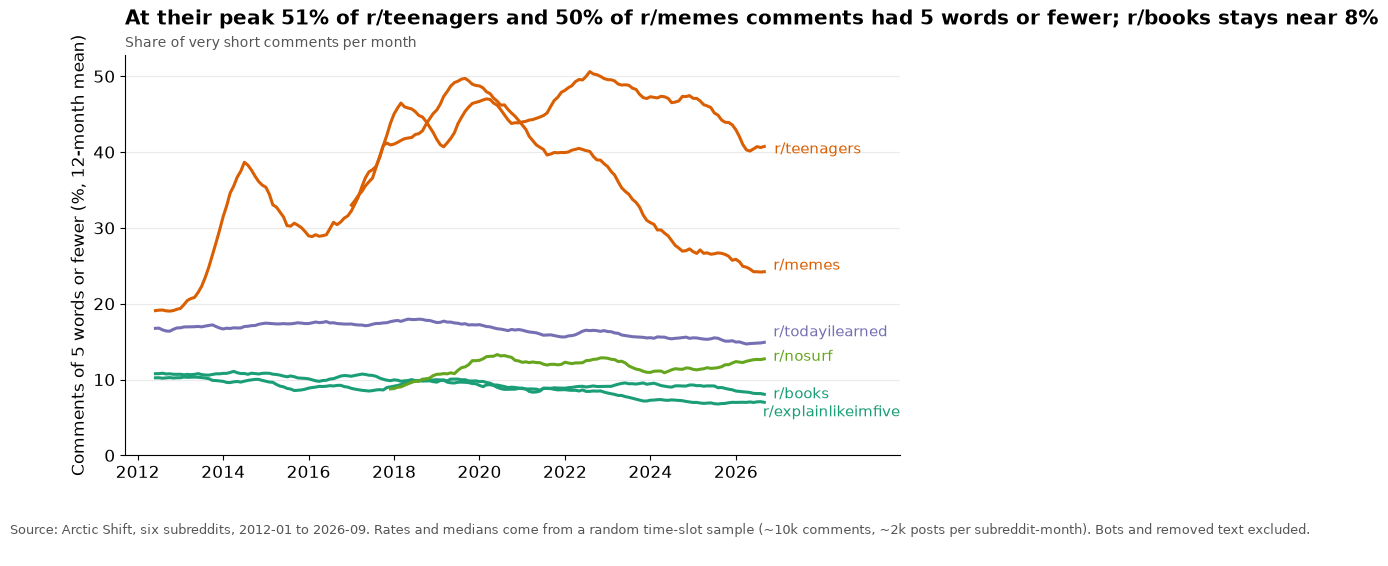

In [3]:
from src import figs_text as figs
_ = figs.c13()
plt.show()

**Code for C13:** `src/figs_text.py` function `c13()`; reads `overview_counts`; built by `python run_pipeline.py aggregates`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q12. Is vocabulary getting poorer? (MTLD, H1)
**Why we asked:** 'Simpler' discourse should show up as less varied vocabulary.

**What we did:** MTLD (measure of textual lexical diversity) on a random sample of 5,000 words per subreddit-month, the same size every month so volume cannot drive the result. Line = 12-month rolling median, band = middle half of those months.

**Result:** MTLD did not fall. Medians for 2012-14 versus 2024-26: r/teenagers 118 to 148, r/memes 130 to 153, r/nosurf 96 to 123, r/todayilearned 123 to 138, r/books 110 to 116, r/explainlikeimfive 93 to 102.

**Interpretation:** The vocabulary of the short-form communities is more varied, not poorer, by this measure. Caution: the sample pools comments from many different people, and short comments from many people add many distinct words (slang, spellings, names); MTLD here describes the community's word variety, not one writer's richness. It does argue against 'simpler vocabulary' in the plain sense.

**Next question:** Is the text also harder or easier to read (Q13)?

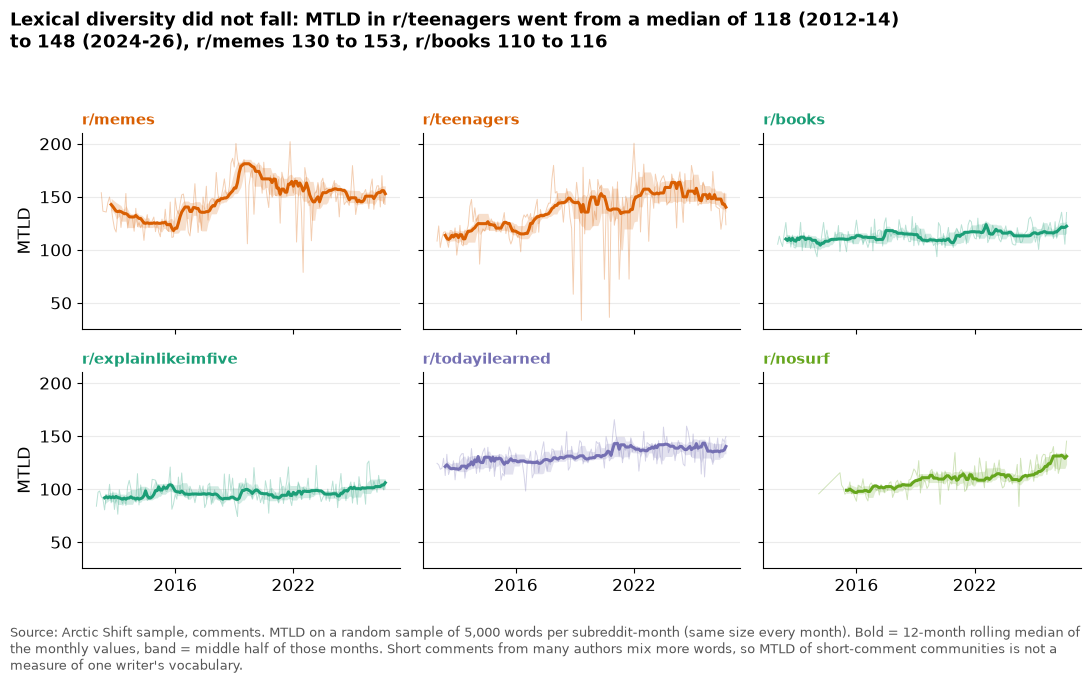

In [4]:
from src import figs_text as figs
_ = figs.c11()
plt.show()

**Code for C11:** `src/figs_text.py` function `c11()`; reads `text_metrics_monthly`; built by `python run_pipeline.py text`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q13. Is the text easier or harder to read? (Flesch, H1)
**Why we asked:** A second view of 'simpler': sentence and word length.

**What we did:** Median Flesch reading ease of comments with 10 or more words (up to 400 per subreddit-month), compared between 2012-14 and 2024-26 in a slope chart.

**Result:** Scores changed by at most 6 points on a 100-point scale, and in the direction of harder reading, not easier: r/memes 80.3 to 74.5, r/teenagers 80.7 to 77.8, r/books 72.6 to 70.6, r/todayilearned 72.0 to 69.9, r/nosurf 72.6 to 71.1, r/explainlikeimfive 67.2 to 66.5.

**Interpretation:** No sign of simplification. Flesch was designed for full sentences; chat-style comments without punctuation score as 'easy' by construction, so the level means little but the direction is informative.

**Next question:** Does the way people write change in other ways, for example emoji (Q14)?

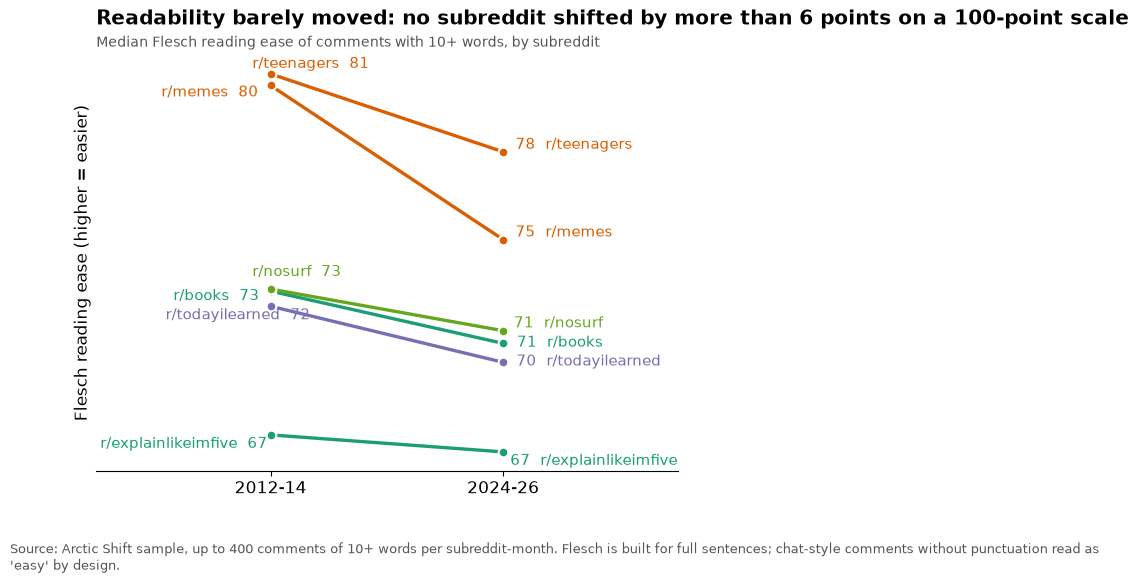

In [5]:
from src import figs_text as figs
_ = figs.c12()
plt.show()

**Code for C12:** `src/figs_text.py` function `c12()`; reads `text_metrics_monthly`; built by `python run_pipeline.py text`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q14. How much do people use emoji?
**Why we asked:** Emoji replace words in short messages and are a visible marker of chat-style writing.

**What we did:** Unicode emoji code points per 10,000 words, per subreddit-month, 12-month mean, months under 50,000 words dropped.

**Result:** r/teenagers peaked at 399 per 10,000 words in January 2018 (4% of all words) and is at 117 now. r/memes peaked at 184 in August 2022 and is at 38. Every other community stays at or below 14 (r/nosurf 14.0, r/books 11.5, r/todayilearned 9.6, r/explainlikeimfive 3.3).

**Interpretation:** Emoji are a short-form community feature. The January 2018 peak is driven by few authors: the five most emoji-heavy authors wrote 61% of the sampled emoji that month. We did not investigate the 2022 peak in r/memes.

**Next question:** Now the central question of H2: do brainrot terms spread (Q15)?

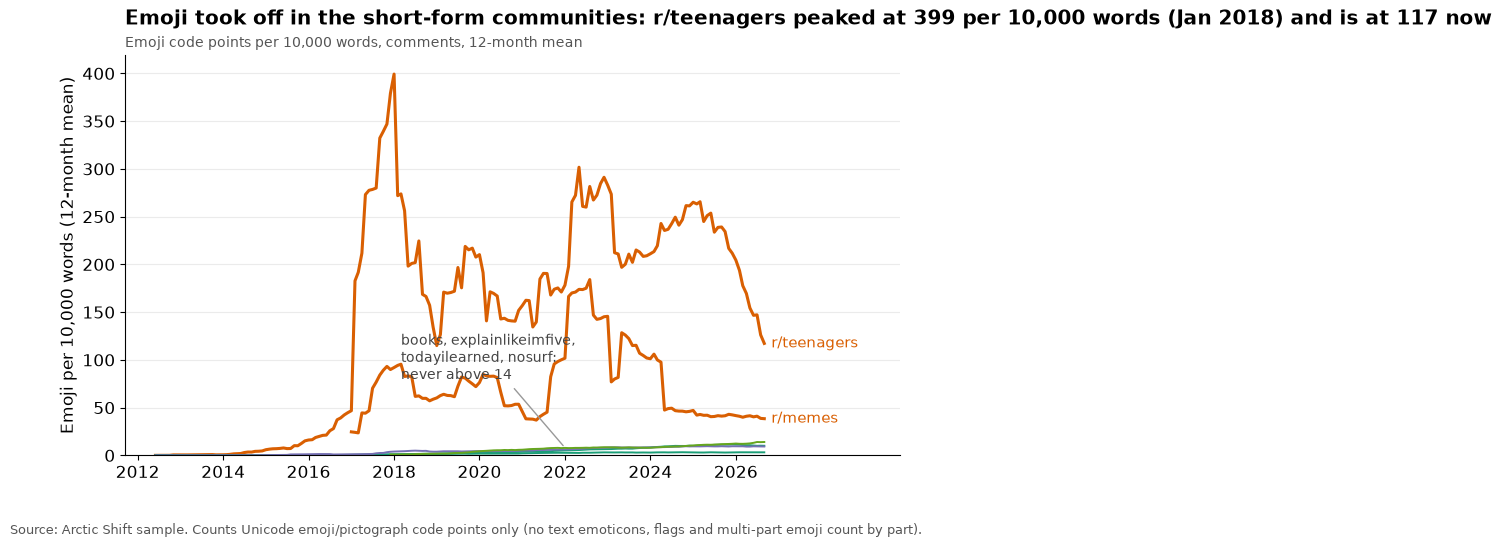

In [6]:
from src import figs_text as figs
_ = figs.c14()
plt.show()

**Code for C14:** `src/figs_text.py` function `c14()`; reads `emoji_monthly`; built by `python run_pipeline.py text`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q15. Do brainrot terms spread, and where? (H2)
**Why we asked:** H2 says short-form platforms accelerated change; the vocabulary is the visible trace on Reddit.

**What we did:** Hits of the core and extended lexicon per 10,000 words (comments), per subreddit-month, small multiples with a shared y-axis. Light line = month, bold line = 3-month mean. Sigma is left out because it is ambiguous.

**Result:** Before 2022 the rate never exceeded 0.2 per 10,000 words. Then it jumped: the highest months were 6.9 in r/memes (November 2023) and 5.5 in r/teenagers (December 2022). In r/teenagers the extended tier (rizz) peaked first, in December 2022 at 5.4, and the core tier (brain rot, skibidi) in mid-2024 at 3.3. By 2026 both short-form communities are back near 0.3-0.5. r/nosurf peaked at 2.0 in January 2025 (core tier only) and is at about 0.8 in recent months; r/explainlikeimfive had a one-off peak of 1.6 in April 2024. r/books and r/todayilearned stay near zero.

**Interpretation:** The slang spiked and faded within about two years in the short-form communities' own talk. In r/nosurf the same words describe media habits (brain rot as a concept) and stay in use. Mentions are not endorsement: many hits are people asking what a word means. The monthly values are noisy because the counts are small (tens of hits).

**Next question:** Which words made up the hits (Q15b), and how many comments contain one (Q16)?

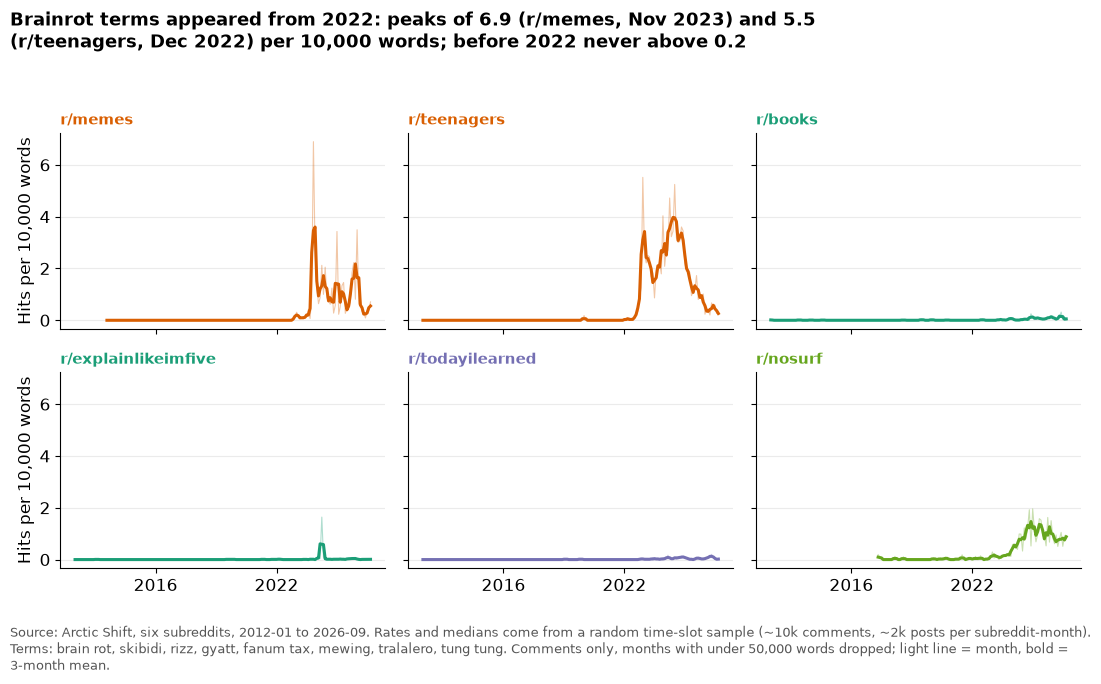

In [7]:
from src import figs_text as figs
_ = figs.c15()
plt.show()

**Code for C15:** `src/figs_text.py` function `c15()`; reads `lexicon_monthly`; built by `python run_pipeline.py text`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q15b. Which terms made up the vocabulary each year?
**Why we asked:** Q15 mixes very different words.

**What we did:** Brainrot terms per 10,000 words (core and extended lexicon, comments of all six subreddits pooled, 3-month mean), stacked by term as a stream graph with a centered baseline: band thickness is the absolute rate of that term. 'brain rot' includes brainrot and brain-rot.

**Result:** In absolute terms the pooled rate of all terms is 0.07 per 10,000 words in 2022, 0.26 in 2023, 0.51 in 2024, 0.43 in 2025 and 0.25 in 2026 (to September), with a 3-month peak of 0.63 in May 2024 for the five terms drawn. Shares of the hits: 2022: rizz is 83%. 2023: rizz 52%, skibidi 23%, gyatt 9%. 2024: skibidi 31%, 'brain rot' (two words) 24% and 'brainrot' 17%. 2025: 'brain rot' 34% and 'brainrot' 38%. 2026 (to September): 'brain rot' 42% and 'brainrot' 41%, with 'tung tung' appearing at 3%.

**Interpretation:** The slang words came and went, while the umbrella term itself took over. By 2025-26 people mostly name the phenomenon rather than use its slang. Only shares are shown because counts are sample hits (about 100 in 2022, 540 in 2023, 1,100 in 2024).

**Next question:** How many comments in a community contain such a word (Q16)?

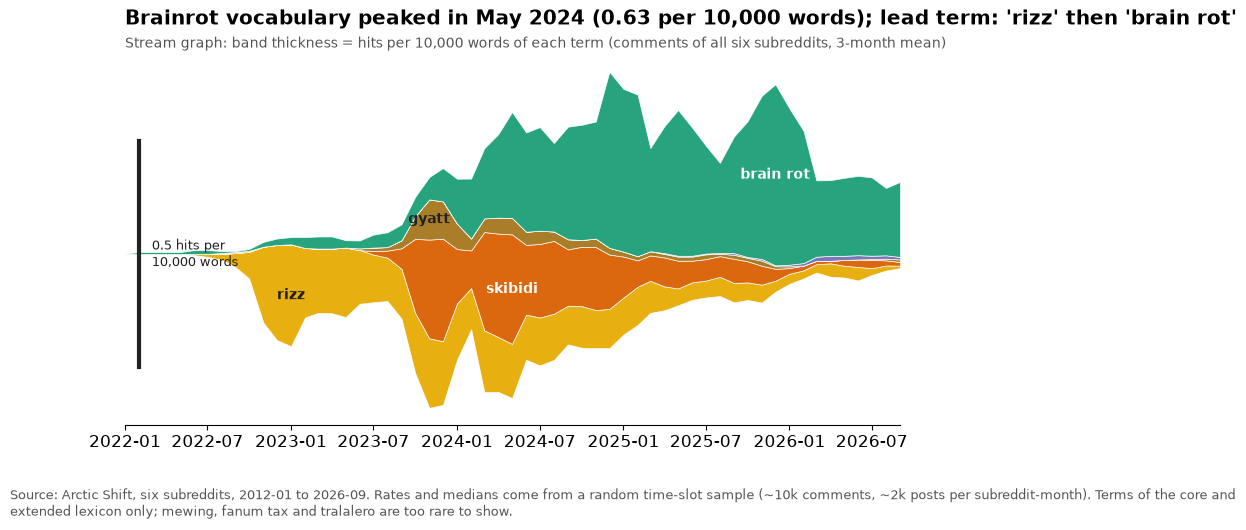

In [8]:
from src import figs_text as figs
_ = figs.c15b()
plt.show()

**Code for C15b:** `src/figs_text.py` function `c15b()`; reads `lexicon_terms_by_month`, `overview_counts`; built by `python run_pipeline.py aggregates, text`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q16. How many comments contain a brainrot term? (reach)
**Why we asked:** A rate per 10,000 words can come from a few long comments; reach counts comments.

**What we did:** Share of comments with at least one core or extended term, per subreddit-month, same layout as Q15.

**Result:** At their peak about 1 in 106 comments in r/memes, 1 in 103 in r/nosurf, 1 in 172 in r/explainlikeimfive and 1 in 183 in r/teenagers contained a term; r/books (1 in 825) and r/todayilearned (1 in 2,600) stay far below.

**Interpretation:** Even at the peak the vocabulary appeared in under 1% of comments. The change is visible in rates but small in the bulk of the discourse (see Q18).

**Next question:** Which other words changed (Q17)?

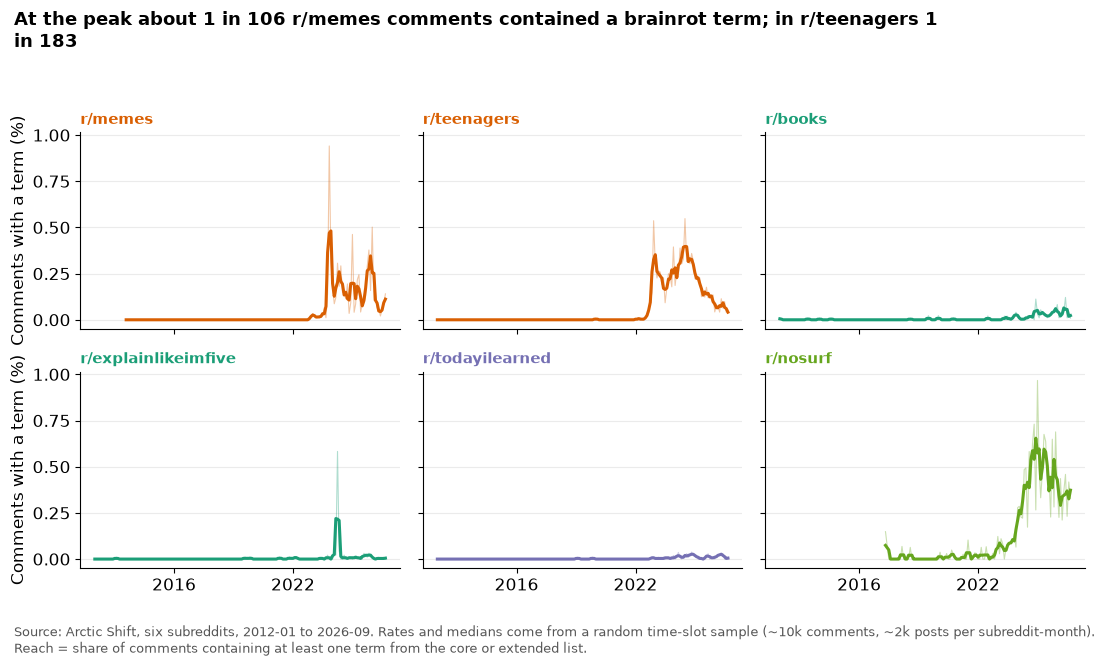

In [9]:
from src import figs_text as figs
_ = figs.c16()
plt.show()

**Code for C16:** `src/figs_text.py` function `c16()`; reads `lexicon_monthly`; built by `python run_pipeline.py text`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q17. Which words gained and lost ground between 2013-16 and 2023-26?
**Why we asked:** Not every change is in our lexicon; this finds changes we did not think of.

**What we did:** Weighted log-odds ratio with an informative prior (Monroe et al. 2008), content words only, comparing 2013-16 with 2023-26, separately for the two short-form and the two long-form communities. Bars show the z-score; diverging layout, gray = earlier period.

**Result:** Short-form (r/memes + r/teenagers): gained bro, women, men, literally, game, people, trans, idk, ur; lost school, friends, really, haha, college, edit, thanks, class. Long-form (r/books + r/explainlikeimfive): gained lol, ai, finished, water, romance, energy, lmao; lost edit, thanks, awesome, government, wage, minimum, movie. Function words also moved when they are included: 'they' and 'is' rise in short-form talk, 'my' and 'her' fall.

**Interpretation:** The short-form shift is a move from school and college life towards talk about gender and slang addressed to 'bro'; it could reflect a change in who writes and what is discussed. 'edit' and 'thanks' fall in both groups (habits of older Reddit that we did not examine further). We cannot separate a change in people from a change in behaviour with these data.

**Next question:** Do the most common phrases change as well (Q18)?

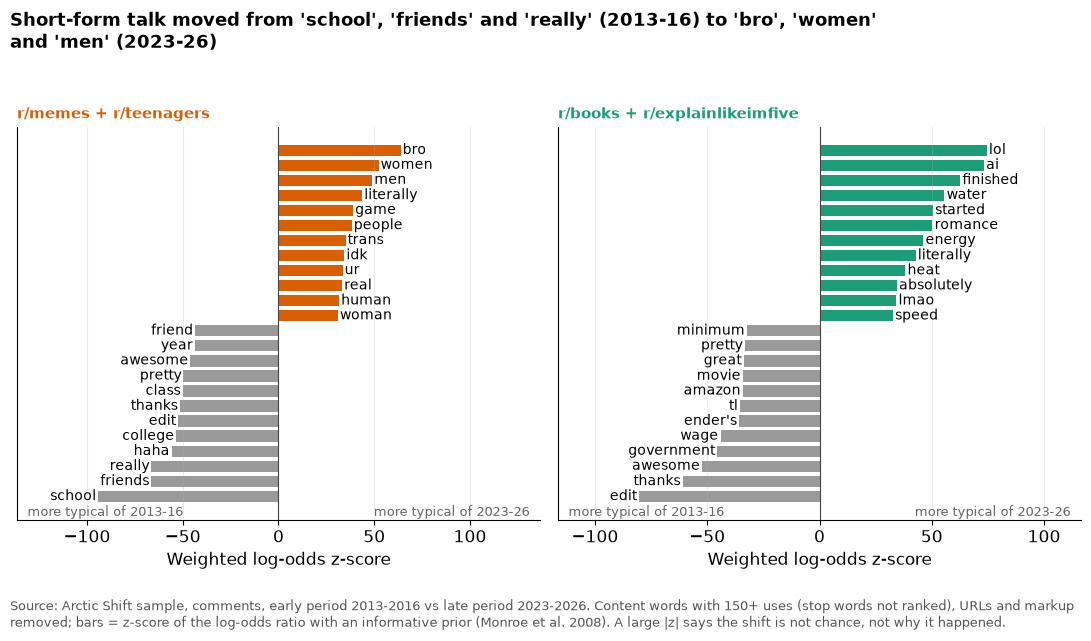

In [10]:
from src import figs_text as figs
_ = figs.c17()
plt.show()

**Code for C17:** `src/figs_text.py` function `c17()`; reads `word_counts_period`; built by `python run_pipeline.py text`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q18. Do the most frequent word pairs change?
**Why we asked:** A check on how much of everyday talk the Q15-Q17 changes represent.

**What we did:** Most frequent word pairs (no stop words, URLs and markup removed) in a fixed random sample of 400,000 comments per group and period; bars per 1,000 comments, colored when the pair is not in the other period's top 40.

**Result:** None changed: all 12 of the most common pairs of 2023-26 were already in the 2013-16 top 40, in both groups. They are everyday phrases: 'don't know', 'feel like', 'don't think', 'it's just'.

**Interpretation:** The bulk of discourse is stable. The brainrot vocabulary of Q15 is too rare to reach the top of a frequency list; it shows only in the dedicated term tracker.

**Next question:** Does the tone of discourse change (Q36)?

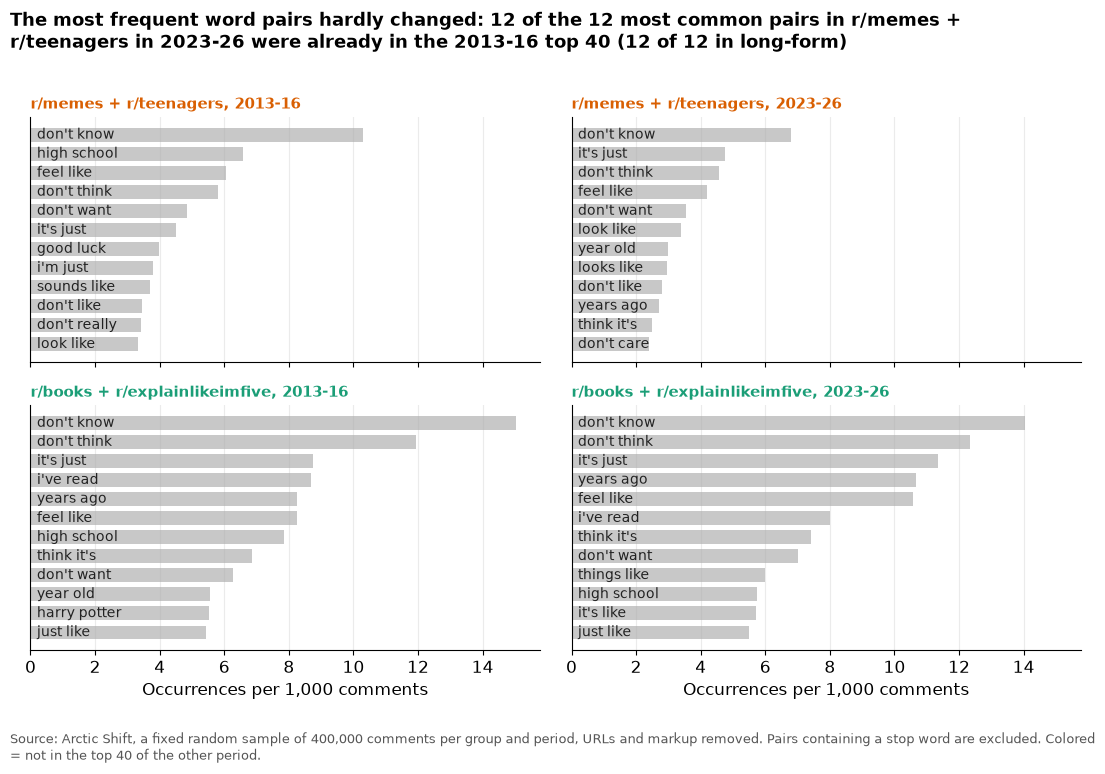

In [11]:
from src import figs_text as figs
_ = figs.c18()
plt.show()

**Code for C18:** `src/figs_text.py` function `c18()`; reads `bigram_counts_period`; built by `python run_pipeline.py text`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q36. Has the tone of comments changed? (sentiment baseline)
**Why we asked:** H4 is about negativity; before looking at crises we need the normal drift of sentiment.

**What we did:** Mean VADER compound score (-1 very negative to +1 very positive) of up to 2,000 random comments per subreddit-month, 12-month mean.

**Result:** Comments became less positive in four communities: r/nosurf 0.36 (2017) to 0.16, r/teenagers 0.17 (2012) to 0.05, r/books 0.27 (2013) to 0.17, r/memes 0.06 to 0.04. r/explainlikeimfive (0.13 to 0.12) and r/todayilearned (about 0.04 throughout) are flat. r/memes and r/todayilearned are the least positive today (about 0.04), r/books the most (0.17).

**Interpretation:** A slow decline in positive tone over many years, long before any crisis date, is the baseline against which crisis effects must be measured (Phase 4). Caveats: VADER is a word list and misreads sarcasm (frequent in r/memes); it has not yet been compared with hand-labeled comments; sentiment of the text says nothing about the writers' mood.

**Next question:** Do crises change tone in communities that are not about news (H4)?

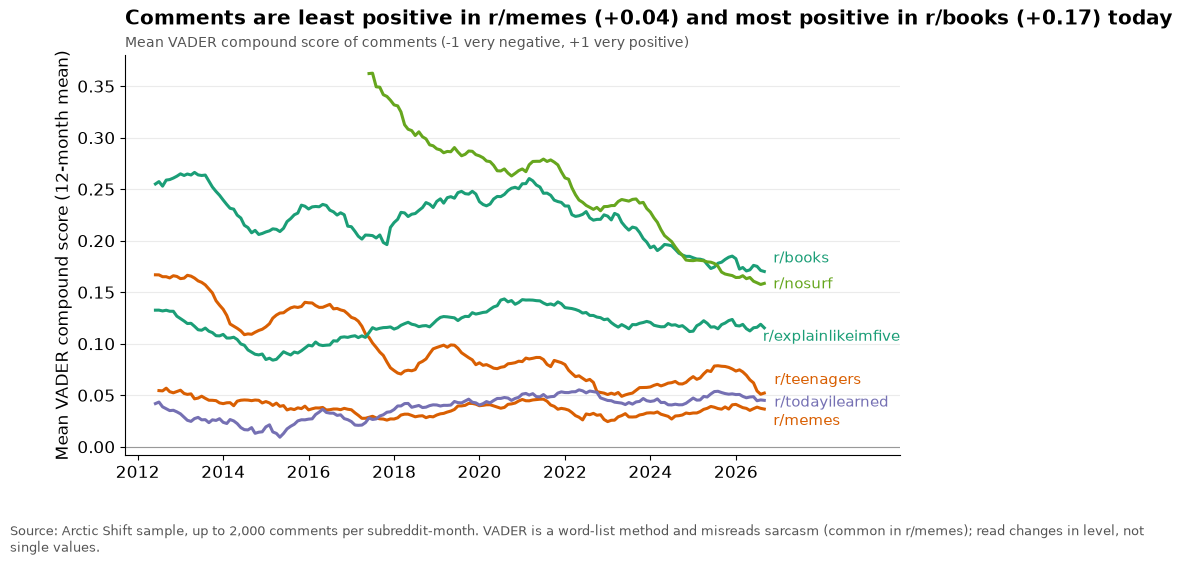

In [12]:
from src import figs_text as figs
_ = figs.c36()
plt.show()

**Code for C36:** `src/figs_text.py` function `c36()`; reads `text_metrics_monthly`; built by `python run_pipeline.py text`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.